# 2026.9.23(수) 21h~ 퍼셉트론

In [1]:
import tensorflow as tf
import numpy as np

import matplotlib.pyplot as plt
import platform
from matplotlib import font_manager
import mat_kor

2026-09-28 19:35:14.326177: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


### 단일/층 퍼셉트론의 구조와 한계

In [3]:
seed = 0
np.random.seed(seed)
tf.random.set_seed(seed)

# and를 구현한 데이터만 줌, and라는 규칙은 알려주지 않음, 
x_data = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)
y_data = np.array([[0],[0],[0],[1]], dtype=np.float32)

W = tf.Variable(tf.random.uniform([2,1], dtype=tf.float32))
b = tf.Variable(tf.random.uniform([1], dtype=tf.float32))

def hypothesis(W, b):
    return tf.sigmoid(tf.matmul(x_data, W) + b) # 행렬 곱

def costFunc():
    return - tf.reduce_mean(y_data * tf.math.log(hypothesis(W, b)) + (1 - y_data) * tf.math.log(1 - hypothesis(W, b)))

opt = tf.keras.optimizers.SGD(learning_rate=0.01)
epoch_arr = []
cost_arr = []
accuracy_arr = []

for i in range(2001):
    with tf.GradientTape() as tape:
        current_cost = costFunc()
    grads = tape.gradient(current_cost, [W,b])
    opt.apply_gradients(zip(grads, [W,b]))
    
    predicted = tf.cast(hypothesis(W, b) > 0.5, dtype=tf.float32) # true 1.0 vs false 0.0(실수)
    epoch_arr.append(i)
    cost_arr.append(current_cost.numpy())
    accuracy = tf.reduce_mean(tf.cast(tf.equal(predicted, y_data), dtype=tf.float64))
    accuracy_arr.append(accuracy)

    if i % 200 == 0:
        print(f'epochs={i}, cost={current_cost.numpy()}, accuracy={accuracy.numpy()}, W1={W.numpy()[0,0]}, W2={W.numpy()[1,0]}, b={b.numpy()}')

print("\n==학습 결과=====================")
print("W = ", W.numpy())
print("b = ", b.numpy()[0])
print("y_data = ", y_data)
print("sigmoid = ", hypothesis(W, b).numpy())
print("predicted = ", predicted.numpy())
print("accuracy = ", accuracy.numpy())

def logistic_predict(X):
    z = tf.matmul(X,W) + b
    return tf.sigmoid(z)

new_x = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=np.float32)

new_y = logistic_predict(new_x)
new_y_result = tf.cast(new_y > 0.5, dtype=tf.int32) # true 1 or false 0

for i in range(len(new_x)):
    print("\n==예측 결과=====================")
    print("입력: [%d, %d]" % (new_x[i][0], new_x[i][1]))
    print("예측(확률): %6.2F %%" % new_y.numpy()[i][0])
    print("예측(이진): ", '1' if new_y_result.numpy()[i][0] == 1 else '0')

epochs=0, cost=0.9142559766769409, accuracy=0.25, W1=0.290871262550354, W2=0.20550815761089325, b=[0.5510173]
epochs=200, cost=0.6639434099197388, accuracy=0.75, W1=0.17714115977287292, W2=0.10140527039766312, b=[-0.12471726]
epochs=400, cost=0.5791430473327637, accuracy=0.75, W1=0.20273326337337494, W2=0.13579675555229187, b=[-0.52855545]
epochs=600, cost=0.5332546234130859, accuracy=0.75, W1=0.2869972288608551, W2=0.22754140198230743, b=[-0.8029599]
epochs=800, cost=0.49888861179351807, accuracy=0.75, W1=0.39279627799987793, W2=0.3397655189037323, b=[-1.0144039]
epochs=1000, cost=0.4699203372001648, accuracy=0.75, W1=0.5042614936828613, W2=0.45682814717292786, b=[-1.1925223]
epochs=1200, cost=0.444587379693985, accuracy=0.75, W1=0.6145956516265869, W2=0.5720828771591187, b=[-1.3511522]
epochs=1400, cost=0.42212578654289246, accuracy=0.75, W1=0.7210229635238647, W2=0.6828588843345642, b=[-1.4970709]
epochs=1600, cost=0.4020532965660095, accuracy=0.75, W1=0.8225916028022766, W2=0.78828

### 2026.9.23(수) 22h~

In [2]:
import numpy as np
import tensorflow as tf

# XOR 연산 데이터 준비
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

# 은닉층 가중치(2x2)와 편향(2) 정의
W1 = tf.Variable(tf.random.normal([2, 2]))
b1 = tf.Variable(tf.random.normal([2]))

# 출력층 가중치(2x1)와 편향(1) 정의
W2 = tf.Variable(tf.random.normal([2, 1]))
b2 = tf.Variable(tf.random.normal([1]))

# 활성화 함수 (sigmoid)
def sigmoid(x):
    return 1 / (1 + tf.exp(-x))

# 다층 퍼셉트론 정의 (은닉층 -> 출력층)
def perceptron(x):
    # 은닉층 연산
    hidden = sigmoid(tf.matmul(x, W1) + b1)
    # 출력층 연산
    return sigmoid(tf.matmul(hidden, W2) + b2)

# 손실 함수 정의 (이진 크로스 엔트로피)
def loss_fn(y_true, y_pred):
    return tf.reduce_mean(-(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred)))

# optimizers 정의 (SGD)
optimizer = tf.keras.optimizers.SGD(learning_rate=0.5)

# 결과를 0 또는 1로 변환하는 함수 정의
def binary_output(x):
    return int(x.numpy()[0][0] > 0.5)

# 정확도 계산 함수 정의
def accuracy(y_true, y_pred):
    correct_prediction = tf.equal(tf.cast(y_pred > 0.5, tf.float32), y_true)
    return tf.reduce_mean(tf.cast(correct_prediction, tf.float32))

# 학습 과정
for epoch in range(2000):
    with tf.GradientTape() as tape:
        pred = perceptron(X)
        loss = loss_fn(y, pred)
    gradients = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2]))

    # 500번마다 학습 과정 출력
    if (epoch + 1) % 500 == 0:
        W1_val = np.squeeze(W1.numpy())
        b1_val = np.squeeze(b1.numpy())
        W2_val = np.squeeze(W2.numpy())
        b2_val = np.squeeze(b2.numpy())
        print(f"step = {epoch+1}, cost = {loss.numpy():.9f}")
        print(f"W1 = {W1_val}, b1 = {b1_val}")
        print(f"W2 = {W2_val}, b2 = {b2_val}")
        print("----------------------------------------")

# 학습 결과 출력
for input_data in X:
    prediction = perceptron(np.array([input_data], dtype=np.float32))
    print(f"입력: {input_data.tolist()}, 예측(확률): {prediction.numpy()[0][0]:.4f}, 예측(이진): {binary_output(prediction)}")

# 정확도 출력
predictions = perceptron(X)
acc = accuracy(y, predictions)
print(f"정확도: {acc.numpy():.4f}")

step = 500, cost = 0.149278060
W1 = [[ 4.552704  -3.8670897]
 [-4.7312965  3.5579295]], b1 = [-2.8441157 -1.9755157]
W2 = [5.6846585 5.1423154], b2 = -2.5906903743743896
----------------------------------------
step = 1000, cost = 0.034265161
W1 = [[ 5.628223  -5.378005 ]
 [-5.7843204  5.067494 ]], b1 = [-3.2033703 -2.8065317]
W2 = [8.147212  8.1406765], b2 = -3.970964193344116
----------------------------------------
step = 1500, cost = 0.018459018
W1 = [[ 6.0120707 -5.861813 ]
 [-6.184742   5.5575895]], b1 = [-3.3639724 -3.0644155]
W2 = [9.268257 9.311383], b2 = -4.542827606201172
----------------------------------------
step = 2000, cost = 0.012516193
W1 = [[ 6.2387958 -6.1380043]
 [-6.422929   5.8375387]], b1 = [-3.4640849 -3.2088563]
W2 = [ 9.9843645 10.039433 ], b2 = -4.903021335601807
----------------------------------------
입력: [0.0, 0.0], 예측(확률): 0.0146, 예측(이진): 0
입력: [0.0, 1.0], 예측(확률): 0.9886, 예측(이진): 1
입력: [1.0, 0.0], 예측(확률): 0.9890, 예측(이진): 1
입력: [1.0, 1.0], 예측(확률): 0.0126

# 2026.9.28(월) 19h~ 다층 퍼셉트론 + 오차 역전파

### 노드 4개인 모델?로 바꿔보기(~19h30)

In [3]:
# import numpy as np
# import tensorflow as tf

# XOR 연산 데이터 준비
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

# 은닉층 가중치(2x4)와 편향(4) 정의
W1 = tf.Variable(tf.random.normal([2, 4]))
b1 = tf.Variable(tf.random.normal([4]))

# 출력층 가중치(4x1)와 편향(1) 정의
W2 = tf.Variable(tf.random.normal([4, 1]))
b2 = tf.Variable(tf.random.normal([1]))

# 활성화 함수 (sigmoid)
def sigmoid(x):
    return 1 / (1 + tf.exp(-x))

# 다층 퍼셉트론 정의 (은닉층 -> 출력층)
def perceptron(x):
    # 은닉층 연산
    hidden = sigmoid(tf.matmul(x, W1) + b1)
    # 출력층 연산
    return sigmoid(tf.matmul(hidden, W2) + b2)

# 손실 함수 정의 (이진 크로스 엔트로피)
def loss_fn(y_true, y_pred):
    return tf.reduce_mean(-(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred)))

# optimizers 정의 (SGD)
optimizer = tf.keras.optimizers.SGD(learning_rate=0.5)

# 결과를 0 또는 1로 변환하는 함수 정의
def binary_output(x):
    return int(x.numpy()[0][0] > 0.5)

# 정확도 계산 함수 정의
def accuracy(y_true, y_pred):
    correct_prediction = tf.equal(tf.cast(y_pred > 0.5, tf.float32), y_true)
    return tf.reduce_mean(tf.cast(correct_prediction, tf.float32))

# 학습 과정
for epoch in range(2000):
    with tf.GradientTape() as tape:
        pred = perceptron(X)
        loss = loss_fn(y, pred)
    gradients = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2]))

    # 500번마다 학습 과정 출력
    if (epoch + 1) % 500 == 0:
        W1_val = np.squeeze(W1.numpy())
        b1_val = np.squeeze(b1.numpy())
        W2_val = np.squeeze(W2.numpy())
        b2_val = np.squeeze(b2.numpy())
        print(f"step = {epoch+1}, cost = {loss.numpy():.9f}")
        print(f"W1 = {W1_val}, b1 = {b1_val}")
        print(f"W2 = {W2_val}, b2 = {b2_val}")
        print("----------------------------------------")

# 학습 결과 출력
for input_data in X:
    prediction = perceptron(np.array([input_data], dtype=np.float32))
    print(f"입력: {input_data.tolist()}, 예측(확률): {prediction.numpy()[0][0]:.4f}, 예측(이진): {binary_output(prediction)}")

# 정확도 출력
predictions = perceptron(X)
acc = accuracy(y, predictions)
print(f"정확도: {acc.numpy():.4f}")

step = 500, cost = 0.426945448
W1 = [[ 0.6878318  -0.988385   -3.7372856   3.1881356 ]
 [ 0.83065605  1.120771    3.3508098   2.1705022 ]], b1 = [-0.66981155 -0.25418663  2.6230915  -4.7736497 ]
W2 = [ 0.9802729  1.2664366 -3.2134728 -3.2208133], b2 = 2.092461347579956
----------------------------------------
step = 1000, cost = 0.034665596
W1 = [[ 2.532096  -3.1793394 -5.3320074  4.251837 ]
 [ 3.5995939  3.685602   4.845392   3.3020854]], b1 = [-1.1350461 -2.1314867  3.3092976 -6.0566964]
W2 = [ 4.414482   5.1802135 -6.5929756 -5.3175926], b2 = 1.6766027212142944
----------------------------------------
step = 1500, cost = 0.013531885
W1 = [[ 3.1519494 -3.8464313 -5.612366   4.4385123]
 [ 4.0866137  4.2095957  5.1918483  3.5950844]], b1 = [-1.3876257 -2.3942473  3.4039361 -6.3573065]
W2 = [ 5.311812   6.2414017 -7.443834  -5.937131 ], b2 = 1.5524375438690186
----------------------------------------
step = 2000, cost = 0.008150248
W1 = [[ 3.4594653 -4.171303  -5.751604   4.534251 ]
 [ 

## hidden layer 2개로 만들어보기

In [ ]:
import numpy as np
import tensorflow as tf

# XOR 연산 데이터 준비
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

# 은닉층 가중치(2x2)와 편향(2) 정의
W1 = tf.Variable(tf.random.normal([2, 2]))
b1 = tf.Variable(tf.random.normal([2]))

# 출력층 가중치(2x1)와 편향(1) 정의
W2 = tf.Variable(tf.random.normal([2, 1]))
b2 = tf.Variable(tf.random.normal([1]))

# 활성화 함수 (sigmoid)
def sigmoid(x):
    return 1 / (1 + tf.exp(-x))

# 다층 퍼셉트론 정의 (은닉층 -> 출력층)
def perceptron(x):
    # 은닉층 연산
    hidden = sigmoid(tf.matmul(x, W1) + b1)
    # 출력층 연산
    return sigmoid(tf.matmul(hidden, W2) + b2)

# 손실 함수 정의 (이진 크로스 엔트로피)
def loss_fn(y_true, y_pred):
    return tf.reduce_mean(-(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred)))

# optimizers 정의 (SGD)
optimizer = tf.keras.optimizers.SGD(learning_rate=0.5)

# 결과를 0 또는 1로 변환하는 함수 정의
def binary_output(x):
    return int(x.numpy()[0][0] > 0.5)

# 정확도 계산 함수 정의
def accuracy(y_true, y_pred):
    correct_prediction = tf.equal(tf.cast(y_pred > 0.5, tf.float32), y_true)
    return tf.reduce_mean(tf.cast(correct_prediction, tf.float32))

# 학습 과정
for epoch in range(2000):
    with tf.GradientTape() as tape:
        pred = perceptron(X)
        loss = loss_fn(y, pred)
    gradients = tape.gradient(loss, [W1, b1, W2, b2])
    optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2]))

    # 500번마다 학습 과정 출력
    if (epoch + 1) % 500 == 0:
        W1_val = np.squeeze(W1.numpy())
        b1_val = np.squeeze(b1.numpy())
        W2_val = np.squeeze(W2.numpy())
        b2_val = np.squeeze(b2.numpy())
        print(f"step = {epoch+1}, cost = {loss.numpy():.9f}")
        print(f"W1 = {W1_val}, b1 = {b1_val}")
        print(f"W2 = {W2_val}, b2 = {b2_val}")
        print("----------------------------------------")

# 학습 결과 출력
for input_data in X:
    prediction = perceptron(np.array([input_data], dtype=np.float32))
    print(f"입력: {input_data.tolist()}, 예측(확률): {prediction.numpy()[0][0]:.4f}, 예측(이진): {binary_output(prediction)}")

# 정확도 출력
predictions = perceptron(X)
acc = accuracy(y, predictions)
print(f"정확도: {acc.numpy():.4f}")

### ~20h30 나의 답변
1. 경사하강법은 모델의 오차를 최소화하는 파라미터를 찾아가는 알고리즘이다. 경사하강법은 손실 함수의 기울기를 학습률만큼 조정하며 가중치를 업데이트하는 과정이다.
2. hidden layer(node)는 비선형성을 도입하여 선형회귀로 풀 수 없는 XOR 문제를 해결할 수 있게 한다. node는 설명선에 꺾이는 부분을 추가하게 되고, hidden layer는 꺾이는 정도를 조절하게 된다.
3. 기울기 사라짐 문제는 hidden layer의 활성화 함수로써 sigmoid 함수를 사용했을 때 은닉층이 늘어날 때마다 미분 값이 0에 가까워지며 기울기가 너무 작은 수가 되는 문제이다. 이 문제가 발생하는 원인은 sigmoid 함수가 0~1 사이의 값을 가지는데, 이 실수에 대한 미분 값이 점점 더 작아지기 때문이다. 이를 해결하기 위해 활성화 함수로써 ReLu 등을 도입하게 되었다.

### 강사님 예시 답변
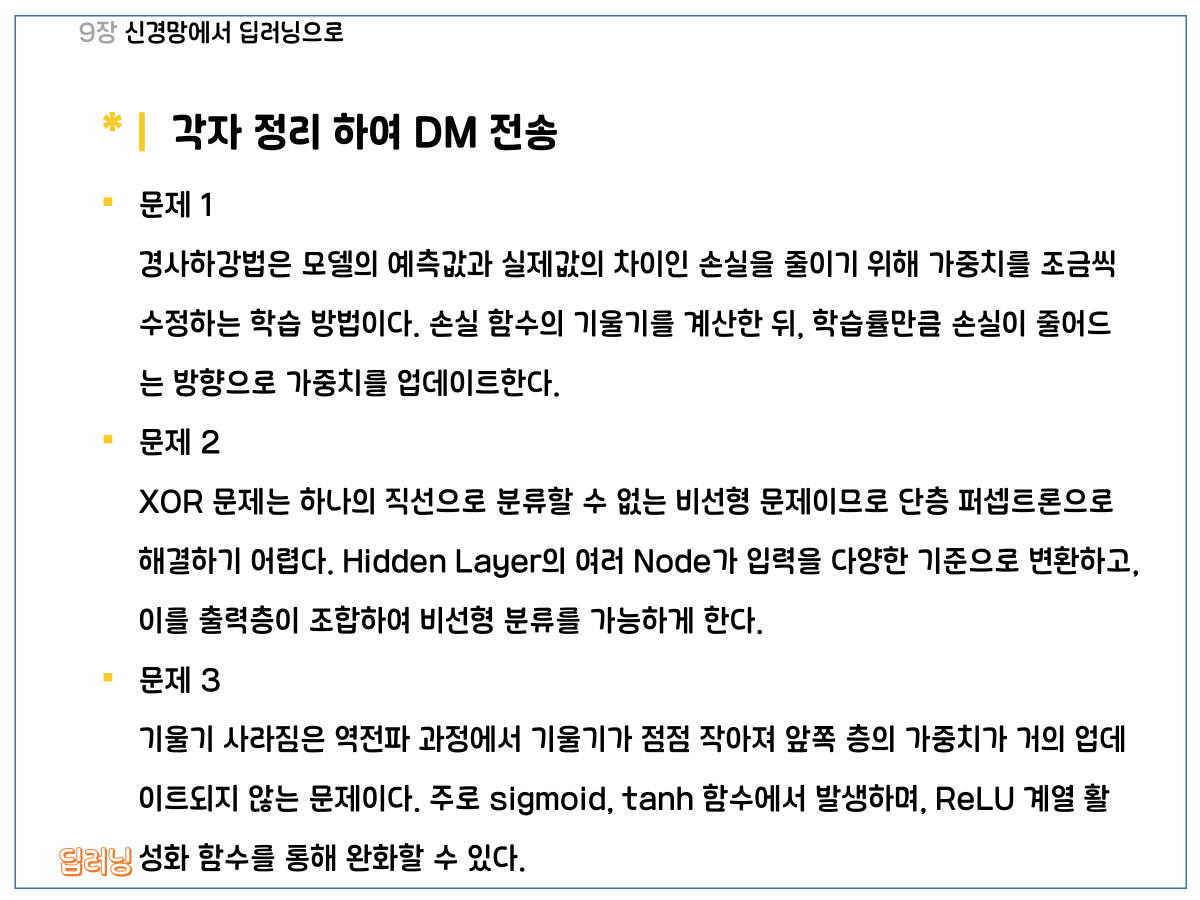